Loaded methods: ['bm25_unibigram', 'bm25_unigram', 'tfidf_char_3_5', 'tfidf_unigram', 'tfidf_unigram_nostop', 'tfidf_unigram_phrases_add', 'tfidf_unigram_phrases_replace']
Total queries: 16590
Saved pairs: /work/eval/bootstrap_sigtests_pairs.csv
Saved leaderboard: /work/eval/bootstrap_sigtests_leaderboard.csv
Saved Markdown report: /work/eval/bootstrap_report.md

Done.


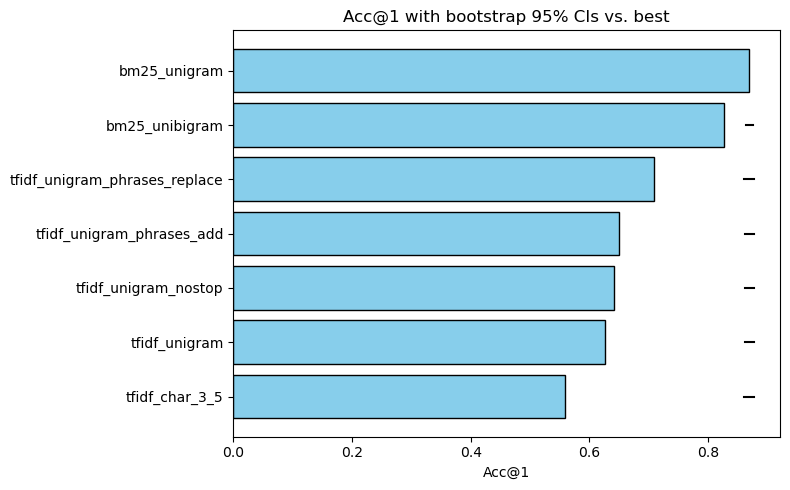

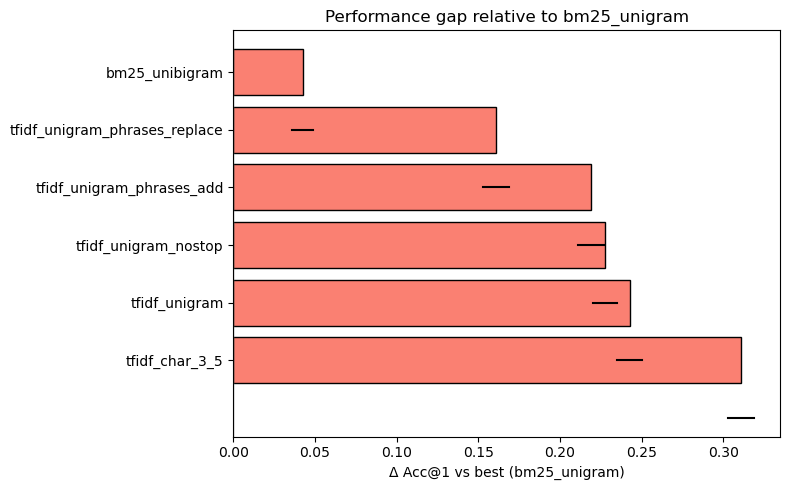

In [10]:
# bootstrap_sigtests.ipynb
# Paired bootstrap (Acc@1) + FWER/FDR corrections + pretty leaderboard
# Saves everything under /work/evals

import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# Config
# -----------------------------
RUNS_DIR   = Path("/work/runs")
EVALS_DIR  = Path("/work/eval")
EVALS_DIR.mkdir(parents=True, exist_ok=True)

N_BOOT = 10000          # bootstrap iterations
ALPHA  = 0.05           # significance level
RNG    = np.random.default_rng(0)

# Keep only canonical BM25 variants
BM25_KEEP = {"bm25_unigram", "bm25_unibigram"}

# -----------------------------
# Load per-query Acc@1
# -----------------------------
def load_acc1_series(run_dir: Path):
    """
    Load per-query Acc@1 flags from results_perquery_summary.csv
    (produced by metrics.ipynb). Returns: pd.Series[int] indexed by query_item_key.
    """
    p = run_dir / "results_perquery_summary.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p, usecols=["query_item_key","acc1_item"])
    s = df.set_index("query_item_key")["acc1_item"].astype(int)
    return s

runs = {}
for d in sorted([p for p in RUNS_DIR.iterdir() if p.is_dir()]):
    name = d.name
    # Keep only canonical BM25 variants among bm25*
    if name.startswith("bm25") and name not in BM25_KEEP:
        continue
    s = load_acc1_series(d)
    if s is not None and len(s) > 0:
        runs[name] = s

if not runs:
    raise RuntimeError("No runs found with per-query summaries. "
                       "Make sure metrics.ipynb created results_perquery_summary.csv in each run.")

# Align all methods on the union of queries (missing → 0)
all_queries = sorted(set().union(*[s.index for s in runs.values()]))
X = pd.DataFrame({m: s.reindex(all_queries).fillna(0).astype(int) for m, s in runs.items()})
methods = X.columns.tolist()

print(f"Loaded methods: {methods}")
print(f"Total queries: {len(all_queries)}")

# -----------------------------
# Paired bootstrap helper
# -----------------------------
def paired_bootstrap_diff(a: np.ndarray, b: np.ndarray, n_boot: int, rng: np.random.Generator):
    """
    Returns bootstrap distribution of mean(a) - mean(b)
    by resampling query indices with replacement (paired).
    """
    n = a.shape[0]
    diffs = np.empty(n_boot, dtype=np.float64)
    for t in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[t] = a[idx].mean() - b[idx].mean()
    return diffs

# -----------------------------
# Pairwise comparisons
# -----------------------------
pairs = []
arr = X.to_numpy()  # shape: [N_queries, N_methods]
for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if j <= i:
            continue
        a = arr[:, i]
        b = arr[:, j]
        diffs = paired_bootstrap_diff(a, b, N_BOOT, RNG)
        delta = a.mean() - b.mean()
        ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
        # one-sided p for "m1 > m2?" (flip if delta <= 0)
        if delta >= 0:
            p_raw = (np.sum(diffs <= 0) + 1) / (N_BOOT + 1)
        else:
            p_raw = (np.sum(diffs >= 0) + 1) / (N_BOOT + 1)
        pairs.append(dict(
            m1=m1, m2=m2,
            delta=delta,
            ci_low=ci_lo, ci_high=ci_hi,
            p_raw=p_raw
        ))

df_pairs = pd.DataFrame(pairs).sort_values(["m1","m2"]).reset_index(drop=True)

# -----------------------------
# Multiple testing corrections
# -----------------------------
def holm_bonferroni(pvals: np.ndarray):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    # step-down (Holm): monotone max with descending multipliers
    for rank, idx in enumerate(order, start=1):
        adj[idx] = min(pvals[idx] * (m - rank + 1), 1.0)
    # enforce monotonicity non-decreasing along sorted order
    adj_sorted = adj[order]
    adj_sorted = np.maximum.accumulate(adj_sorted[::-1])[::-1]
    adj[order] = adj_sorted
    return adj

def benjamini_hochberg(pvals: np.ndarray):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m, dtype=float)
    running_min = 1.0
    for rank, idx in reversed(list(enumerate(order, start=1))):
        val = pvals[idx] * m / rank
        running_min = min(running_min, val)
        adj[idx] = min(running_min, 1.0)
    return adj

df_pairs["p_holm"] = holm_bonferroni(df_pairs["p_raw"].to_numpy())
df_pairs["p_bh"]   = benjamini_hochberg(df_pairs["p_raw"].to_numpy())
df_pairs["sig_holm"] = df_pairs["p_holm"] < ALPHA
df_pairs["sig_bh"]   = df_pairs["p_bh"]   < ALPHA

# Save full pairwise table
PAIRS_CSV = EVALS_DIR / "bootstrap_sigtests_pairs.csv"
df_pairs.to_csv(PAIRS_CSV, index=False)
print("Saved pairs:", PAIRS_CSV)

# -----------------------------
# Leaderboard + significance vs best
# -----------------------------
leader = (
    pd.DataFrame({"method": methods, "Acc@1": X.mean(axis=0).to_list()})
    .sort_values("Acc@1", ascending=False)
    .reset_index(drop=True)
)
best_method = leader.iloc[0]["method"]
best_acc    = leader.iloc[0]["Acc@1"]

def find_pair(m1, m2):
    """Return the row comparing (m1 vs m2) regardless of order."""
    r = df_pairs[(df_pairs["m1"]==m1) & (df_pairs["m2"]==m2)]
    if not r.empty:
        return r.iloc[0]
    r = df_pairs[(df_pairs["m1"]==m2) & (df_pairs["m2"]==m1)]
    if not r.empty:
        # flip sign/CI when inverted
        r = r.iloc[0].copy()
        r["delta"]  = -r["delta"]
        lo, hi = -r["ci_high"], -r["ci_low"]
        r["ci_low"], r["ci_high"] = lo, hi
        return r
    return None

rows = []
for _, row in leader.iterrows():
    m = row["method"]
    acc = row["Acc@1"]
    if m == best_method:
        rows.append({
            "method": m,
            "Acc@1": acc,
            "delta_vs_best": 0.0,
            "ci95": "[0.000, 0.000]",
            "p_raw": 0.0,
            "p_holm": 0.0,
            "p_bh": 0.0,
            "sig_vs_best_holm": True,
            "sig_vs_best_bh": True
        })
        continue
    pr = find_pair(best_method, m)
    if pr is None:
        rows.append({
            "method": m, "Acc@1": acc,
            "delta_vs_best": np.nan, "ci95": "",
            "p_raw": np.nan, "p_holm": np.nan, "p_bh": np.nan,
            "sig_vs_best_holm": False, "sig_vs_best_bh": False
        })
    else:
        ci_txt = f"[{pr['ci_low']:.4f}, {pr['ci_high']:.4f}]"
        rows.append({
            "method": m, "Acc@1": acc,
            "delta_vs_best": pr["delta"],
            "ci95": ci_txt,
            "p_raw": pr["p_raw"],
            "p_holm": pr["p_holm"],
            "p_bh": pr["p_bh"],
            "sig_vs_best_holm": bool(pr["sig_holm"]),
            "sig_vs_best_bh": bool(pr["sig_bh"]),
        })

leader_sig = (
    pd.DataFrame(rows)
    .merge(leader[["method","Acc@1"]], on=["method","Acc@1"], how="right")
    .sort_values("Acc@1", ascending=False)
    .reset_index(drop=True)
)

LEADER_CSV = EVALS_DIR / "bootstrap_sigtests_leaderboard.csv"
leader_sig.to_csv(LEADER_CSV, index=False)
print("Saved leaderboard:", LEADER_CSV)

# -----------------------------
# Paper-friendly Markdown table
# -----------------------------
def fmt_row(r):
    name = r["method"]
    acc  = r["Acc@1"]
    if name == best_method:
        name_fmt = f"**{name}**"
        acc_fmt  = f"**{acc:.4f}**"
        sig_h, sig_b = "—", "—"
        delta = "—"; ci = "—"
    else:
        name_fmt = name
        acc_fmt  = f"{acc:.4f}"
        # marks: ✓ if significantly worse than best (best > m), ✗ otherwise
        # (If best not significantly better => we mark as '≈' to indicate tie under control)
        if pd.isna(r["p_holm"]):
            sig_h = "?"
        else:
            sig_h = "✓" if r["sig_vs_best_holm"] and (r["delta_vs_best"] > 0) else ("≈" if not r["sig_vs_best_holm"] else "✗")
        if pd.isna(r["p_bh"]):
            sig_b = "?"
        else:
            sig_b = "✓" if r["sig_vs_best_bh"] and (r["delta_vs_best"] > 0) else ("≈" if not r["sig_vs_best_bh"] else "✗")
        delta = f"{r['delta_vs_best']:.4f}"
        ci    = r["ci95"]

    return dict(
        Method=name_fmt,
        Acc1=acc_fmt,
        Δ_vs_best=delta,
        CI95=ci,
        Holm=sig_h,
        BH=sig_b
    )

md_rows = [fmt_row(r) for _, r in leader_sig.iterrows()]
md = "| Method | Acc@1 | Δ vs best | 95% CI | Holm | BH |\n|---|---:|---:|---:|:--:|:--:|\n"
for r in md_rows:
    md += f"| {r['Method']} | {r['Acc1']} | {r['Δ_vs_best']} | {r['CI95']} | {r['Holm']} | {r['BH']} |\n"

REPORT_MD = EVALS_DIR / "bootstrap_report.md"
with open(REPORT_MD, "w", encoding="utf-8") as f:
    f.write("# Bootstrap significance — Acc@1\n\n")
    f.write(f"- Queries: {len(all_queries)}\n")
    f.write(f"- Bootstraps: {N_BOOT}\n")
    f.write(f"- α = {ALPHA}\n")
    f.write(f"- Best method: **{best_method}** (Acc@1 = **{best_acc:.4f}**)\n\n")
    f.write("Legend: Holm = Holm–Bonferroni (FWER), BH = Benjamini–Hochberg (FDR). "
            "`✓` = best is significantly better (method is worse), `≈` = no significant difference, `✗` = opposite direction.\n\n")
    f.write(md)

print("Saved Markdown report:", REPORT_MD)
print("\nDone.")

# -----------------------------
# Visualization: Leaderboard with CIs
# -----------------------------
import matplotlib.pyplot as plt

# Build a DataFrame with Acc@1 and CI vs best
plot_df = leader_sig.copy()
plot_df["Acc@1"] = plot_df["Acc@1"].astype(float)

# Extract CI bounds relative to each method (vs best)
ci_bounds = plot_df["ci95"].str.extract(r"\[([0-9\.\-]+),\s*([0-9\.\-]+)\]")
plot_df["ci_low"] = pd.to_numeric(ci_bounds[0], errors="coerce")
plot_df["ci_high"] = pd.to_numeric(ci_bounds[1], errors="coerce")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

y = np.arange(len(plot_df))
ax.barh(y, plot_df["Acc@1"], color="skyblue", edgecolor="k")

# Add error bars (Acc@1 - Δ vs best CI width)
# For the best method, ci_low/ci_high are NaN, so we skip
for i, r in plot_df.iterrows():
    if pd.notna(r["ci_low"]) and pd.notna(r["ci_high"]):
        # shift CI back to absolute Acc@1 by subtracting delta
        acc = r["Acc@1"]
        lo = acc + (r["ci_low"])   # ci_low is Δ vs best
        hi = acc + (r["ci_high"])
        ax.plot([lo, hi], [i, i], color="k", lw=1.5)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["method"])
ax.invert_yaxis()
ax.set_xlabel("Acc@1")
ax.set_title("Acc@1 with bootstrap 95% CIs vs. best")

plt.tight_layout()
plt.savefig(EVALS_DIR/"bootstrap_plot_leaderboard.png", dpi=150)
plt.show()

# -----------------------------
# Visualization: Δ vs best (Acc@1 difference)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Filter out the best itself (Δ = 0)
diff_df = plot_df[plot_df["method"] != best_method].copy()

# Bar chart of Δ vs best
y = np.arange(len(diff_df))
ax.barh(y, diff_df["delta_vs_best"], color="salmon", edgecolor="k")

# Error bars: directly use ci_low, ci_high (already Δ vs best)
for i, r in diff_df.iterrows():
    if pd.notna(r["ci_low"]) and pd.notna(r["ci_high"]):
        ax.plot([r["ci_low"], r["ci_high"]], [i, i], color="k", lw=1.5)

ax.set_yticks(y)
ax.set_yticklabels(diff_df["method"])
ax.invert_yaxis()
ax.set_xlabel("Δ Acc@1 vs best (bm25_unigram)")
ax.set_title("Performance gap relative to bm25_unigram")

plt.axvline(0, color="grey", lw=1)  # reference line
plt.tight_layout()
plt.savefig(EVALS_DIR/"bootstrap_plot_deltas.png", dpi=150)
plt.show()
